# EDA — POS_CASH_balance.csv

## Step 1 — Import Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
print("Libraries loaded")

Libraries loaded


## Step 2 — Load Data

In [6]:
df = pd.read_csv("data/application_train.csv")
df.columns = df.columns.str.lower().str.strip()
if "target" in df.columns:
    df = df.rename(columns={"target": "default"})

pos = pd.read_csv("data/POS_CASH_balance.csv")
pos.columns = pos.columns.str.lower().str.strip()

print("application_train shape:", df.shape)
print("POS_CASH_balance shape :", pos.shape)

application_train shape: (307511, 122)
POS_CASH_balance shape : (10001358, 8)


## Step 3 

In [8]:
pos.head()

,sk_id_prev,sk_id_curr,months_balance,cnt_instalment,cnt_instalment_future,name_contract_status,sk_dpd,sk_dpd_def
0,1803195,182943,-31,48.0,45.0,Active,0,0
1,1715348,367990,-33,36.0,35.0,Active,0,0
2,1784872,397406,-32,12.0,9.0,Active,0,0
3,1903291,269225,-35,48.0,42.0,Active,0,0
4,2341044,334279,-35,36.0,35.0,Active,0,0


In [9]:
print("=== COLUMNS ===")
print(pos.columns.tolist())
print()
print("=== DATA TYPES ===")
print(pos.dtypes.value_counts())

=== COLUMNS ===
['sk_id_prev', 'sk_id_curr', 'months_balance', 'cnt_instalment', 'cnt_instalment_future', 'name_contract_status', 'sk_dpd', 'sk_dpd_def']

=== DATA TYPES ===
int64      5
float64    2
object     1
Name: count, dtype: int64


## Step 4 — Basic Statistics

In [11]:
pos.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
sk_id_prev,10001358.0,1903216.60,535846.53,1000001.0,1434405.0,1896565.0,2368963.0,2843499.0
sk_id_curr,10001358.0,278403.86,102763.75,100001.0,189550.0,278654.0,367429.0,456255.0
months_balance,10001358.0,-35.01,26.07,-96.0,-54.0,-28.0,-13.0,-1.0
cnt_instalment,9975287.0,17.09,12.00,1.0,10.0,12.0,24.0,92.0
cnt_instalment_future,9975271.0,10.48,11.11,0.0,3.0,7.0,14.0,85.0
sk_dpd,10001358.0,11.61,132.71,0.0,0.0,0.0,0.0,4231.0
sk_dpd_def,10001358.0,0.65,32.76,0.0,0.0,0.0,0.0,3595.0


## Step 5 — Records Per Applicant

In [13]:
print("Unique applicants     :", pos["sk_id_curr"].nunique())
print("Unique previous loans :", pos["sk_id_prev"].nunique())
print("Average records/person:", round(
    len(pos) / pos["sk_id_curr"].nunique(), 2))

Unique applicants     : 337252
Unique previous loans : 936325
Average records/person: 29.66


count    337252.00
mean         29.66
std          24.53
min           1.00
25%          12.00
50%          22.00
75%          39.00
max         295.00
Name: sk_id_prev, dtype: float64


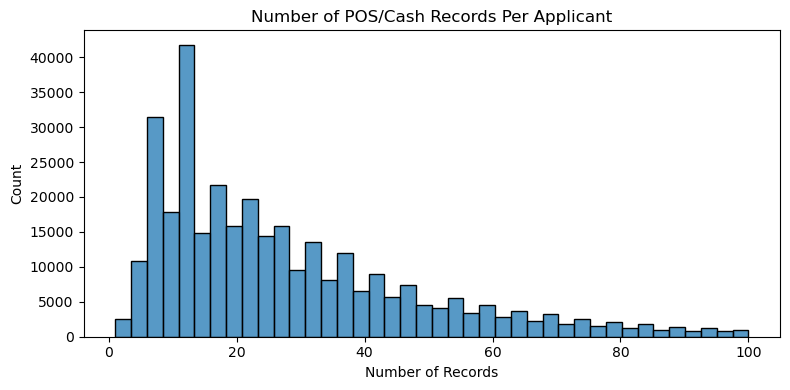

In [14]:
records_per_person = pos.groupby("sk_id_curr")["sk_id_prev"].count()

print(records_per_person.describe().round(2))

plt.figure(figsize=(8, 4))
sns.histplot(records_per_person[records_per_person <= 100], bins=40)
plt.title("Number of POS/Cash Records Per Applicant")
plt.xlabel("Number of Records")
plt.tight_layout()
plt.show()

## Step 6 — Missing Values

In [16]:
missing_pos = (pos.isnull().sum() / len(pos) * 100).round(2)

print("=== MISSING VALUES ===")
if missing_pos[missing_pos > 0].empty:
    print("No significant missing values found")
else:
    print(missing_pos[missing_pos > 0].sort_values(ascending=False))

=== MISSING VALUES ===
cnt_instalment           0.26
cnt_instalment_future    0.26
dtype: float64


## Step 7 — Distribution of Key Columns

=== CONTRACT STATUS ===
name_contract_status
Active                   9151119
Completed                 744883
Signed                     87260
Demand                      7065
Returned to the store       5461
Approved                    4917
Amortized debt               636
Canceled                      15
XNA                            2
Name: count, dtype: int64

name_contract_status
Active                   91.50
Completed                 7.45
Signed                    0.87
Demand                    0.07
Returned to the store     0.05
Approved                  0.05
Amortized debt            0.01
Canceled                  0.00
XNA                       0.00
Name: proportion, dtype: float64


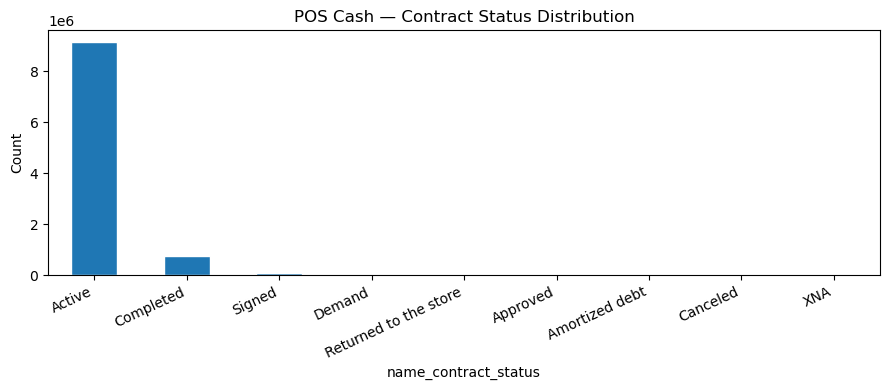

In [18]:
print("=== CONTRACT STATUS ===")
print(pos["name_contract_status"].value_counts())
print()
print((pos["name_contract_status"].value_counts(normalize=True) * 100).round(2))

plt.figure(figsize=(9, 4))
pos["name_contract_status"].value_counts().plot(kind="bar", edgecolor="white")
plt.title("POS Cash — Contract Status Distribution")
plt.ylabel("Count")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

=== INSTALLMENTS REMAINING ===
count    9975271.00
mean          10.48
std           11.11
min            0.00
25%            3.00
50%            7.00
75%           14.00
max           85.00
Name: cnt_instalment_future, dtype: float64


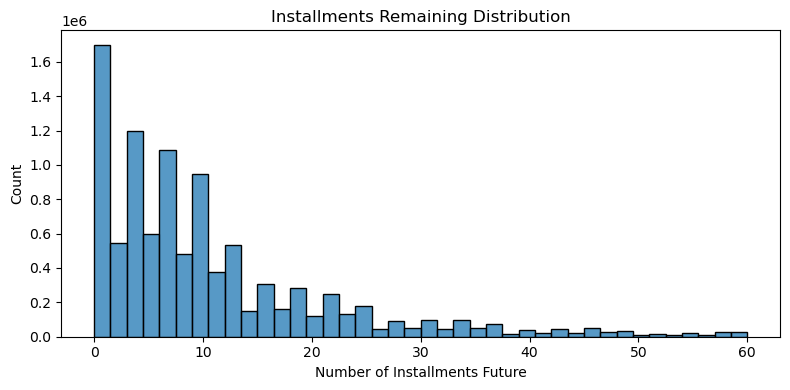

In [19]:
print("=== INSTALLMENTS REMAINING ===")
print(pos["cnt_instalment_future"].describe().round(2))

plt.figure(figsize=(8, 4))
sns.histplot(
    pos[pos["cnt_instalment_future"] <= 60]["cnt_instalment_future"],
    bins=40
)
plt.title("Installments Remaining Distribution")
plt.xlabel("Number of Installments Future")
plt.tight_layout()
plt.show()

In [20]:
print("=== DAYS PAST DUE (sk_dpd) ===")
print(pos["sk_dpd"].describe().round(2))

dpd = (pos["sk_dpd"] > 0).sum()
print()
print("Records with any DPD:", dpd,
      f"({round(dpd / len(pos) * 100, 2)}%)")

print()
print("=== DAYS PAST DUE DEF (sk_dpd_def) ===")
print(pos["sk_dpd_def"].describe().round(2))

=== DAYS PAST DUE (sk_dpd) ===
count    10001358.00
mean           11.61
std           132.71
min             0.00
25%             0.00
50%             0.00
75%             0.00
max          4231.00
Name: sk_dpd, dtype: float64

Records with any DPD: 295227 (2.95%)

=== DAYS PAST DUE DEF (sk_dpd_def) ===
count    10001358.00
mean            0.65
std            32.76
min             0.00
25%             0.00
50%             0.00
75%             0.00
max          3595.00
Name: sk_dpd_def, dtype: float64


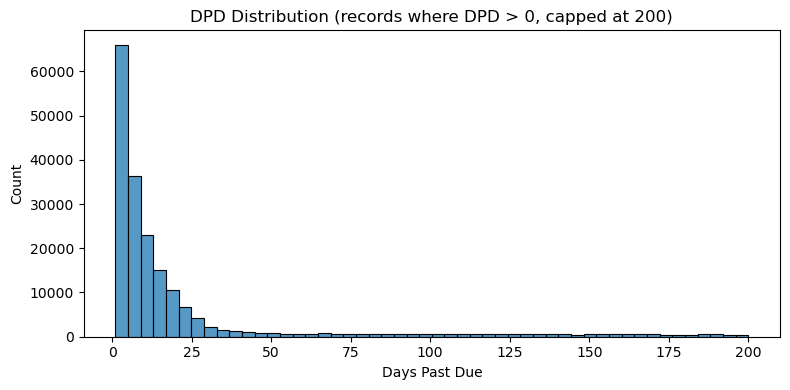

In [21]:
plt.figure(figsize=(8, 4))
dpd_data = pos[(pos["sk_dpd"] > 0) & (pos["sk_dpd"] <= 200)]["sk_dpd"]
sns.histplot(dpd_data, bins=50)
plt.title("DPD Distribution (records where DPD > 0, capped at 200)")
plt.xlabel("Days Past Due")
plt.tight_layout()
plt.show()

=== MONTHS BALANCE ===
0   = current month
-96 = 8 years ago

count    10001358.00
mean          -35.01
std            26.07
min           -96.00
25%           -54.00
50%           -28.00
75%           -13.00
max            -1.00
Name: months_balance, dtype: float64


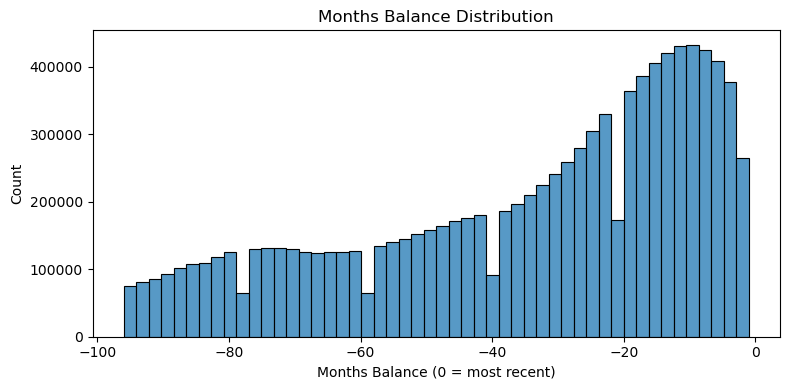

In [22]:
print("=== MONTHS BALANCE ===")
print("0   = current month")
print("-96 = 8 years ago")
print()
print(pos["months_balance"].describe().round(2))

plt.figure(figsize=(8, 4))
sns.histplot(pos["months_balance"], bins=50)
plt.title("Months Balance Distribution")
plt.xlabel("Months Balance (0 = most recent)")
plt.tight_layout()
plt.show()

In [23]:
print("=== INSTALLMENTS TOTAL vs REMAINING ===")
print()
print("Total installments (cnt_instalment):")
print(pos["cnt_instalment"].describe().round(2))
print()
print("Remaining (cnt_instalment_future):")
print(pos["cnt_instalment_future"].describe().round(2))

completed = (pos["cnt_instalment_future"] == 0).sum()
print()
print("Records where all installments completed:",
      completed,
      f"({round(completed / len(pos) * 100, 2)}%)")

=== INSTALLMENTS TOTAL vs REMAINING ===

Total installments (cnt_instalment):
count    9975287.00
mean          17.09
std           12.00
min            1.00
25%           10.00
50%           12.00
75%           24.00
max           92.00
Name: cnt_instalment, dtype: float64

Remaining (cnt_instalment_future):
count    9975271.00
mean          10.48
std           11.11
min            0.00
25%            3.00
50%            7.00
75%           14.00
max           85.00
Name: cnt_instalment_future, dtype: float64

Records where all installments completed: 1185960 (11.86%)


## Step 8 — Coverage Against Main Dataset

In [25]:
main_ids = set(df["sk_id_curr"])
pos_ids  = set(pos["sk_id_curr"])

matched  = len(main_ids & pos_ids)
no_match = len(main_ids - pos_ids)

print("Have POS/Cash records:", matched,
      f"({round(matched / len(main_ids) * 100, 2)}%)")
print("No POS/Cash records  :", no_match,
      f"({round(no_match / len(main_ids) * 100, 2)}%)")

has_pos = df[df["sk_id_curr"].isin(pos_ids)]
no_pos  = df[~df["sk_id_curr"].isin(pos_ids)]

print()
print("Default rate WITH POS/Cash records:",
      round(has_pos["default"].mean() * 100, 2), "%")
print("Default rate WITHOUT records      :",
      round(no_pos["default"].mean() * 100, 2), "%")

Have POS/Cash records: 289444 (94.12%)
No POS/Cash records  : 18067 (5.88%)

Default rate WITH POS/Cash records: 8.16 %
Default rate WITHOUT records      : 6.66 %


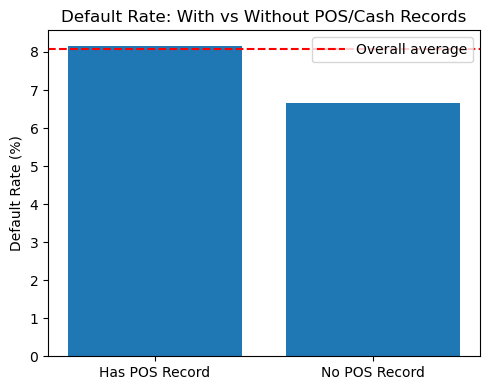

In [26]:
plt.figure(figsize=(5, 4))
plt.bar(
    ["Has POS Record", "No POS Record"],
    [has_pos["default"].mean() * 100,
     no_pos["default"].mean() * 100]
)
plt.title("Default Rate: With vs Without POS/Cash Records")
plt.ylabel("Default Rate (%)")
plt.axhline(df["default"].mean() * 100, color="red",
            linestyle="--", label="Overall average")
plt.legend()
plt.tight_layout()
plt.show()

## Step 9 — Relationship with Target

In [28]:
pos_agg = pos.groupby("sk_id_curr").agg(
    pos_months_count     = ("months_balance", "count"),
    pos_avg_dpd          = ("sk_dpd", "mean"),
    pos_max_dpd          = ("sk_dpd", "max"),
    pos_avg_dpd_def      = ("sk_dpd_def", "mean"),
    pos_dpd_rate         = ("sk_dpd", lambda x: (x > 0).sum() / len(x)),
    pos_completed_count  = ("name_contract_status",
                            lambda x: (x == "Completed").sum()),
    pos_active_count     = ("name_contract_status",
                            lambda x: (x == "Active").sum()),
    pos_avg_instalment   = ("cnt_instalment", "mean"),
    pos_avg_future       = ("cnt_instalment_future", "mean"),
).reset_index()

print("POS aggregated shape:", pos_agg.shape)
print()
print(pos_agg.head())

POS aggregated shape: (337252, 10)

   sk_id_curr  pos_months_count  pos_avg_dpd  pos_max_dpd  pos_avg_dpd_def  \
0      100001                 9     0.777778            7         0.777778   
1      100002                19     0.000000            0         0.000000   
2      100003                28     0.000000            0         0.000000   
3      100004                 4     0.000000            0         0.000000   
4      100005                11     0.000000            0         0.000000   

   pos_dpd_rate  pos_completed_count  pos_active_count  pos_avg_instalment  \
0      0.111111                    2                 7            4.000000   
1      0.000000                    0                19           24.000000   
2      0.000000                    2                26           10.107143   
3      0.000000                    1                 3            3.750000   
4      0.000000                    1                 9           11.700000   

   pos_avg_future  
0     

=== POS CASH FEATURES — CORRELATION WITH DEFAULT ===
pos_active_count      -0.0359
pos_months_count      -0.0356
pos_completed_count   -0.0195
pos_max_dpd            0.0048
pos_avg_dpd            0.0054
pos_avg_dpd_def        0.0065
pos_avg_instalment     0.0181
pos_avg_future         0.0278
pos_dpd_rate           0.0306
Name: default, dtype: float64


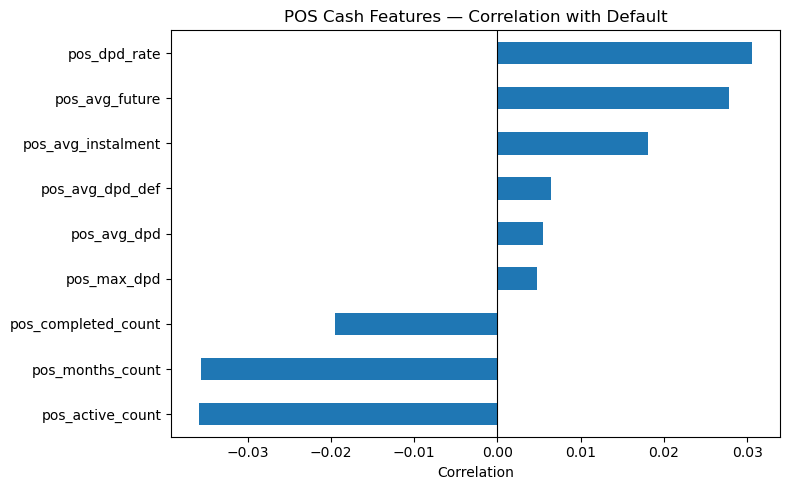

In [29]:
df_pos = df.merge(pos_agg, on="sk_id_curr", how="left")

pos_feat_cols = [c for c in pos_agg.columns if c != "sk_id_curr"]
corr_pos = df_pos[pos_feat_cols + ["default"]].corr()["default"].drop("default")

print("=== POS CASH FEATURES — CORRELATION WITH DEFAULT ===")
print(corr_pos.sort_values().round(4))

plt.figure(figsize=(8, 5))
corr_pos.sort_values().plot(kind="barh")
plt.title("POS Cash Features — Correlation with Default")
plt.xlabel("Correlation")
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

## Step 10 — Outlier Check

In [31]:
pos_num  = pos.select_dtypes(include=np.number).columns.tolist()
excl_pos = ["sk_id_prev", "sk_id_curr", "months_balance"]
check_pos = [c for c in pos_num if c not in excl_pos]

print(f"Checking {len(check_pos)} columns\n")
print(f"{'Column':<35} {'1%':>12} {'99%':>12} {'Max':>15} {'Outlier?'}")
print("-" * 85)

outliers_pos = []
for col in check_pos:
    q01     = pos[col].quantile(0.01)
    q99     = pos[col].quantile(0.99)
    max_val = pos[col].max()
    is_out  = (max_val > q99 * 3) if q99 > 0 else (
               max_val > 100 if q99 == 0 else False)
    flag    = "YES" if is_out else "ok"
    if is_out:
        outliers_pos.append(col)
    print(f"{col:<35} {q01:>12.2f} {q99:>12.2f} {max_val:>15.2f}  {flag}")

print()
print("Outlier columns:")
for c in outliers_pos:
    print(" -", c)

Checking 4 columns

Column                                        1%          99%             Max Outlier?
-------------------------------------------------------------------------------------
cnt_instalment                              4.00        60.00           92.00  ok
cnt_instalment_future                       0.00        53.00           85.00  ok
sk_dpd                                      0.00       235.00         4231.00  YES
sk_dpd_def                                  0.00         1.00         3595.00  YES

Outlier columns:
 - sk_dpd
 - sk_dpd_def


## Observations

- 10,001,358 records, 8 columns.
- 94.12% of main dataset applicants have POS/Cash records — good coverage.
- Almost no missing values — only 0.26% in cnt_instalment and cnt_instalment_future.
- 91.50% of records are Active contracts — most loans are still running.
- Average 29.66 monthly records per applicant.
- Very few records show days past due — most applicants pay on time.
- sk_dpd max is 4,231 — extreme outlier.
- Best correlation feature pos_dpd_rate is only +0.031 — weakest signals of all datasets.
- Low signal strength is the main reason this dataset may be excluded from modeling.